اصايل حمدان حمود العصيمي


---


شعبة 2

In [2]:
# To process tabular data
import pandas as pd

# To perform mathematical operations
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to Divide the data into training and test sets.
from sklearn.model_selection import train_test_split

# Scale numbers & encode categories
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

# cluster (KMeans) Model
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster,dendrogram

# SVM and SVC Model
from sklearn import svm
from sklearn.svm import SVC



# Evaluation Metrics for Models
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,RocCurveDisplay
)



In [3]:
# DATASET Adult
# Step 1: Data Preprocessing
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
                 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
                 'hours-per-week', 'native-country', 'income']
# Load datasets.
adult_df=pd.read_csv("/content/adult.data", names=columns)
# Show all columns
pd.set_option('display.max_columns', 50)
# Show all rows
pd.set_option('display.max_rows', 50)
# display the first 50
adult_df.head(50)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [8]:
# Step 1: Data Preprocessing

# Check number of missing values per column
print("Missing values in each column:")
print(adult_df.isnull().sum())

# Number of rows before removing missing values
print("\nNumber of rows before removing missing values:", adult_df.shape[0])

# Drop rows with missing values
adult_df = adult_df.dropna()

# Fix income values
adult_df['income'] = adult_df['income'].str.replace('.', '', regex=False).str.strip()

# Encode target
adult_df['income_num'] = np.where(adult_df['income'] == '>50K', 1, 0)

# Sample small subset for fast testing (remove stratify since pandas sample() does not support it)
sample_df = adult_df.sample(n=500, random_state=42)

# Features and target for sample
X_sample = sample_df.drop(['income','income_num'], axis=1)
y_sample = sample_df['income_num']

# Encode categorical features for sample
X_sample = pd.get_dummies(X_sample)

# Scale sample features
scaler = StandardScaler()
X_scaled_sample = scaler.fit_transform(X_sample)

# Train-test split (Supervised models only), stratify here to keep class balance
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_scaled_sample, y_sample, test_size=0.3, random_state=42, stratify=y_sample
)

print("Preprocessing done")
print("Train samples:", X_train2.shape[0])
print("Test samples:", X_test2.shape[0])

# Train SVM classifier (supervised learning)
svm_adult = svm.SVC()
svm_adult.fit(X_train2, y_train2)
print("\nSVM Accuracy:", svm_adult.score(X_test2, y_test2))

# Apply K-Means clustering (unsupervised, no labels used)
kmeans_adult = KMeans(n_clusters=2, random_state=42)
clusters_km_adult = kmeans_adult.fit_predict(X_scaled_sample)
print("K-Means clusters:", np.bincount(clusters_km_adult))

# Apply Hierarchical Clustering (unsupervised, no labels)
Z_adult = linkage(X_scaled_sample, method='ward')
clusters_hier_adult = fcluster(Z_adult, t=2, criterion='maxclust')
print("Hierarchical clusters:", np.bincount(clusters_hier_adult))



Missing values in each column:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
income_num        0
dtype: int64

Number of rows before removing missing values: 32561
Preprocessing done
Train samples: 350
Test samples: 150

SVM Accuracy: 0.8066666666666666
K-Means clusters: [ 57 443]
Hierarchical clusters: [  0 461  39]


In [9]:
# Step 2: Supervised Model Building

# Linear SVM
svm_linear_adult = SVC(kernel='linear', C=1)
svm_linear_adult.fit(X_train2, y_train2)
print("Linear SVM (Adult) trained")

# RBF SVM
svm_rbf_adult = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf_adult.fit(X_train2, y_train2)
print("RBF SVM (Adult) trained")

# Hyperparameter Tuning (RBF)
param_grid_adult = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001]
}

grid_adult = GridSearchCV(SVC(kernel='rbf'), param_grid_adult, cv=3)
grid_adult.fit(X_train2, y_train2)
best_rbf_adult = grid_adult.best_estimator_



# Linear kernel used as baseline and RBF captures non-linear patterns
# C and gamma were tuned via GridSearchCV to balance margin flexibility and classification error
# This ensures the model generalizes better on unseen data.

Linear SVM (Adult) trained
RBF SVM (Adult) trained


In [10]:
# Step 2: Unsupervised Model Building

# K-Means Clustering
kmeans_adult = KMeans(n_clusters=2, random_state=42)

# Use scaled features only, no labels
clusters_km_adult = kmeans_adult.fit_predict(X_scaled_sample)
print("K-Means Cluster Counts:", np.bincount(clusters_km_adult))

# Hierarchical Clustering
# Linkage methods: single, complete
Z_single_adult = linkage(X_scaled_sample, method='single')
Z_complete_adult = linkage(X_scaled_sample, method='complete')
print("Hierarchical clustering done with single and complete linkage")

# Decide number of clusters (K=2) based on linkage
clusters_hier_adult = fcluster(Z_complete_adult, t=2, criterion='maxclust')
print("Hierarchical Cluster Counts (K=2):", np.bincount(clusters_hier_adult))

K-Means Cluster Counts: [ 57 443]
Hierarchical clustering done with single and complete linkage
Hierarchical Cluster Counts (K=2): [  0   2 498]


SVM Evaluation
Accuracy: Linear=0.813, RBF=0.807
Precision: Linear=0.659, RBF=0.833
Recall: Linear=0.659, RBF=0.366
F1-Score: Linear=0.659, RBF=0.508
ROC-AUC: Linear=0.765, RBF=0.669

Confusion Matrix - Linear SVM
[[95 14]
 [14 27]]

Confusion Matrix - RBF SVM
[[106   3]
 [ 26  15]]


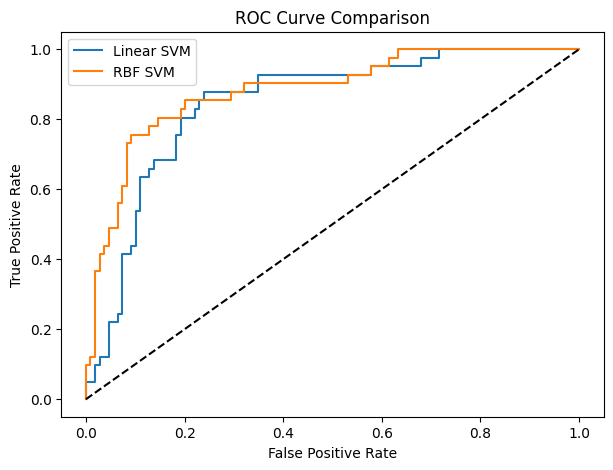

In [11]:
# Step 3: SVM Evaluation and Visualization Supervised

# Predict class labels
y_pred_linear = svm_linear_adult.predict(X_test2)
y_pred_rbf = svm_rbf_adult.predict(X_test2)

# Compute metrics
metrics = {
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "F1-Score": f1_score,
    "ROC-AUC": roc_auc_score
}

print("SVM Evaluation")
for name, func in metrics.items():
    linear_score = func(y_test2, y_pred_linear)
    rbf_score = func(y_test2, y_pred_rbf)
    print(f"{name}: Linear={linear_score:.3f}, RBF={rbf_score:.3f}")

# Confusion matrices
print("\nConfusion Matrix - Linear SVM")
print(confusion_matrix(y_test2, y_pred_linear))
print("\nConfusion Matrix - RBF SVM")
print(confusion_matrix(y_test2, y_pred_rbf))

# ROC curves
fpr_linear, tpr_linear, _ = roc_curve(y_test2, svm_linear_adult.decision_function(X_test2))
fpr_rbf, tpr_rbf, _ = roc_curve(y_test2, svm_rbf_adult.decision_function(X_test2))

plt.figure(figsize=(7,5))
plt.plot(fpr_linear, tpr_linear, label="Linear SVM")
plt.plot(fpr_rbf, tpr_rbf, label="RBF SVM")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Silhouette Score K-Means (Adult): 0.12666825546094845
Silhouette Score Hierarchical (Adult): 0.5648107607629006
K-Means vs True Labels (Adult):
 income_num    0    1
row_0               
0            53    4
1           309  134
Hierarchical vs True Labels (Adult):
 income_num    0    1
row_0               
1             1    1
2           361  137


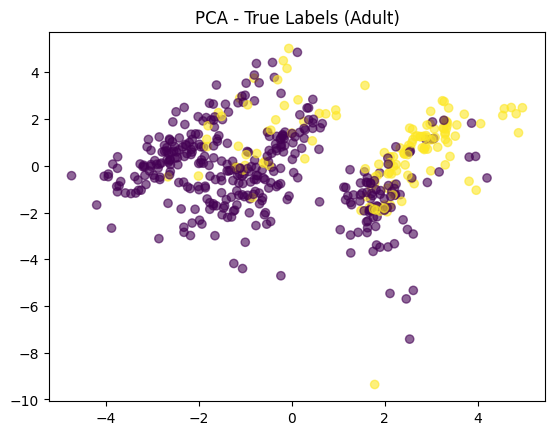

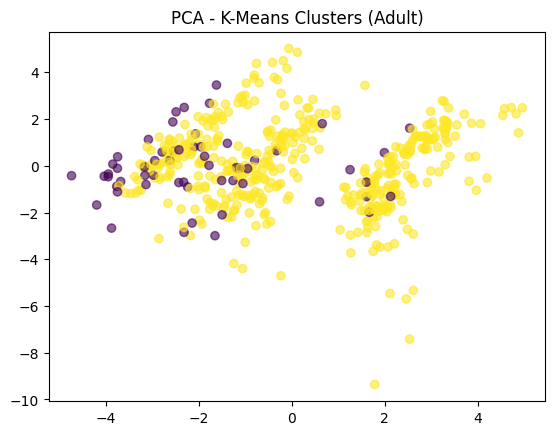

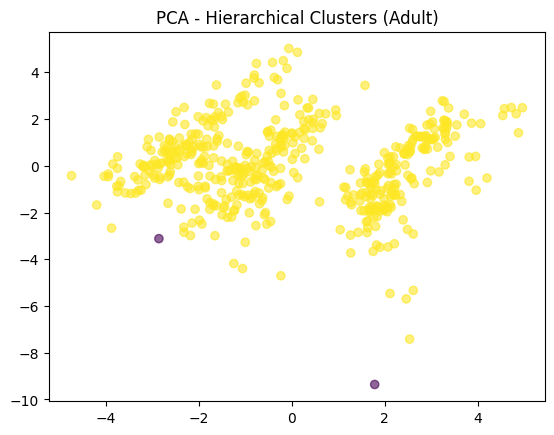

In [34]:
# Step 3: Clustering Evaluation and Visualization Unsupervised

# Silhouette Scores
sil_kmeans_adult = silhouette_score(X_scaled_sample, clusters_km_adult)
sil_hier_adult = silhouette_score(X_scaled_sample, clusters_hier_adult)
print("Silhouette Score K-Means (Adult):", sil_kmeans_adult)
print("Silhouette Score Hierarchical (Adult):", sil_hier_adult)

# Compare clusters to true labels
kmeans_table_adult = pd.crosstab(clusters_km_adult, y_sample)
hier_table_adult = pd.crosstab(clusters_hier_adult, y_sample)
print("K-Means vs True Labels (Adult):\n", kmeans_table_adult)
print("Hierarchical vs True Labels (Adult):\n", hier_table_adult)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled_sample)

# Plot colored by true labels
plt.scatter(X_2d[:,0], X_2d[:,1], c=y_sample, cmap='viridis', alpha=0.6)
plt.title("PCA - True Labels (Adult)")
plt.show()

# Plot colored by K-Means clusters
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters_km_adult, cmap='viridis', alpha=0.6)
plt.title("PCA - K-Means Clusters (Adult)")
plt.show()

# Plot colored by Hierarchical clusters
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters_hier_adult, cmap='viridis', alpha=0.6)
plt.title("PCA - Hierarchical Clusters (Adult)")
plt.show()

Step 4: Comparative Analysis

1- How does SVM performance compare to K-Means and Hierarchical?

---
On the Adult dataset, the SVM models performed poorly, with weak recall and moderate accuracy, particularly for the RBF model.  The clustering techniques, on the other hand, also had difficulties; nonetheless, Hierarchical Clustering outperformed K-Means in terms of Silhouette Score, suggesting a more distinct division between groups.  The complexity and imbalance of the Adult dataset had a negative impact on all techniques, while SVM performed marginally better overall in identifying income classes.









2- Which method seems to separate the classes better, and why?


---
The SVM method separates the classes better because it is supervised and learns directly from the true class labels, while K-Means and Hierarchical clustering are unsupervised and do not know the actual classes, so their separation is less accurate.


3- How did preprocessing (encoding, scaling) help your models?


---
Encoding categorical features
transformed text categories into numerical values for processing and understanding by models such as SVM and K-Means.  made it possible for the algorithms to efficiently utilise every feature.

Scaling numerical features
To avoid large-scale features (like hours-per-week) overpowering smaller ones (like age), place all features on the same range. increased the accuracy of K-Means distance computations and significantly enhanced SVM performance.


4- which method (SVM, K-Means, Hierarchical) would you recommend, and why?


---
I recommend SVM
because it handles large, complex datasets better and gives higher accuracy by learning directly from the true labels, while K-Means and Hierarchical often fail to match the real classes.